In [60]:
# 1. Install the pgmpy library which provides tools for Bayesian Networks
!pip install pgmpy

In [61]:
# 2. Import core libraries for data handling (pandas/numpy) and PGM modeling
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split

# Set seed for reproducibility of results
np.random.seed(42)

In [62]:
# 3. Load and Preprocess the Dataset
# We load the CSV and discretize continuous variables like 'Age' to work with the Discrete PGM model.
file_path = '/content/heart_disease_risk_dataset_earlymed.csv'
df = pd.read_csv(file_path)

processed_df = df.copy()

# Group Age into categories: Young, Middle-Aged, and Senior
processed_df['Age'] = pd.cut(df['Age'], bins=[0, 40, 60, 100], labels=['Young', 'Middle-Aged', 'Senior'])
processed_df = processed_df.rename(columns={'Heart_Risk': 'Disease'})

# Convert all columns to strings to ensure they are treated as categorical data
processed_df = processed_df.astype(str)

display(processed_df.head())
print("\nUnique values per column:")
print(processed_df.nunique())

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Disease
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,Middle-Aged,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,Middle-Aged,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,Senior,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,Middle-Aged,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Senior,0.0



Unique values per column:
Chest_Pain             2
Shortness_of_Breath    2
Fatigue                2
Palpitations           2
Dizziness              2
Swelling               2
Pain_Arms_Jaw_Back     2
Cold_Sweats_Nausea     2
High_BP                2
High_Cholesterol       2
Diabetes               2
Smoking                2
Obesity                2
Sedentary_Lifestyle    2
Family_History         2
Chronic_Stress         2
Gender                 2
Age                    3
Disease                2
dtype: int64


In [63]:
# 4. Build and Train the Medical Hierarchy (Bayesian Network Structure)
# Here we define the causal relationships (edges) based on clinical logic.
from pgmpy.estimators import BayesianEstimator

model = DiscreteBayesianNetwork([
    ('Age', 'High_BP'),
    ('High_BP', 'Disease'),
    ('Age', 'Diabetes'),
    ('Diabetes', 'Disease'),
    ('Smoking', 'High_BP'),
    ('Obesity', 'High_BP'),
    ('Obesity', 'Diabetes'),
    ('Diabetes', 'High_BP'),
    ('High_Cholesterol', 'Disease'),
    ('Family_History', 'Disease'),
    ('Gender', 'Disease'),
    ('Disease', 'Chest_Pain')
])

# Train using Bayesian Estimator with BDeu prior for better generalization
model.fit(processed_df, estimator=BayesianEstimator, prior_type='BDeu')

print(f"Final Ideal Model Consistent: {model.check_model()}")

Final Ideal Model Consistent: True


In [64]:
# 5. Evaluate Model Performance
# Splitting the data to check how well the model predicts the 'Disease' node on unseen data.
from sklearn.metrics import accuracy_score, classification_report, f1_score

train_data, test_data = train_test_split(processed_df, test_size=0.2, random_state=42)
model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
infer = VariableElimination(model)

y_true = test_data['Disease'].values
y_pred = []

# Perform inference for each test sample (Inference can be time-intensive for large test sets)
for index, row in test_data.iloc[:500].iterrows():
    evidence = {k: v for k, v in row.items() if k in model.nodes() and k != 'Disease'}
    result = infer.map_query(variables=['Disease'], evidence=evidence, show_progress=False)
    y_pred.append(result['Disease'])

# Note: Metrics calculated here are based on the subset for speed in this demonstration
print("Detailed Classification Report (Subset Sample):")
print(classification_report(y_true[:500], y_pred))

Detailed Classification Report (Subset Sample):
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89       225
         1.0       0.91      0.90      0.91       275

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



In [65]:
# 6. Basic Inference Engine
# A helper function to query the network for specific patient profiles.
infer = VariableElimination(model)

def predict_heart_disease(patient_data):
    evidence = {k: str(v) for k, v in patient_data.items() if k in model.nodes() and k != 'Disease'}
    result = infer.query(variables=['Disease'], evidence=evidence)

    prob_no = result.values[0]
    prob_yes = result.values[1]
    prediction = "Yes" if prob_yes > prob_no else "No"

    print("--- Prediction Results ---")
    print(f"Prediction: {prediction} (P(Disease=1): {prob_yes:.4f})")
    return prob_yes

sample_patient = {'Age': 'Senior', 'High_BP': '1.0', 'High_Cholesterol': '1.0', 'Smoking': '1.0', 'Diabetes': '1.0', 'Obesity': '1.0'}
predict_heart_disease(sample_patient)

--- Prediction Results ---
Prediction: Yes (P(Disease=1): 0.8967)


np.float64(0.8967000107016024)

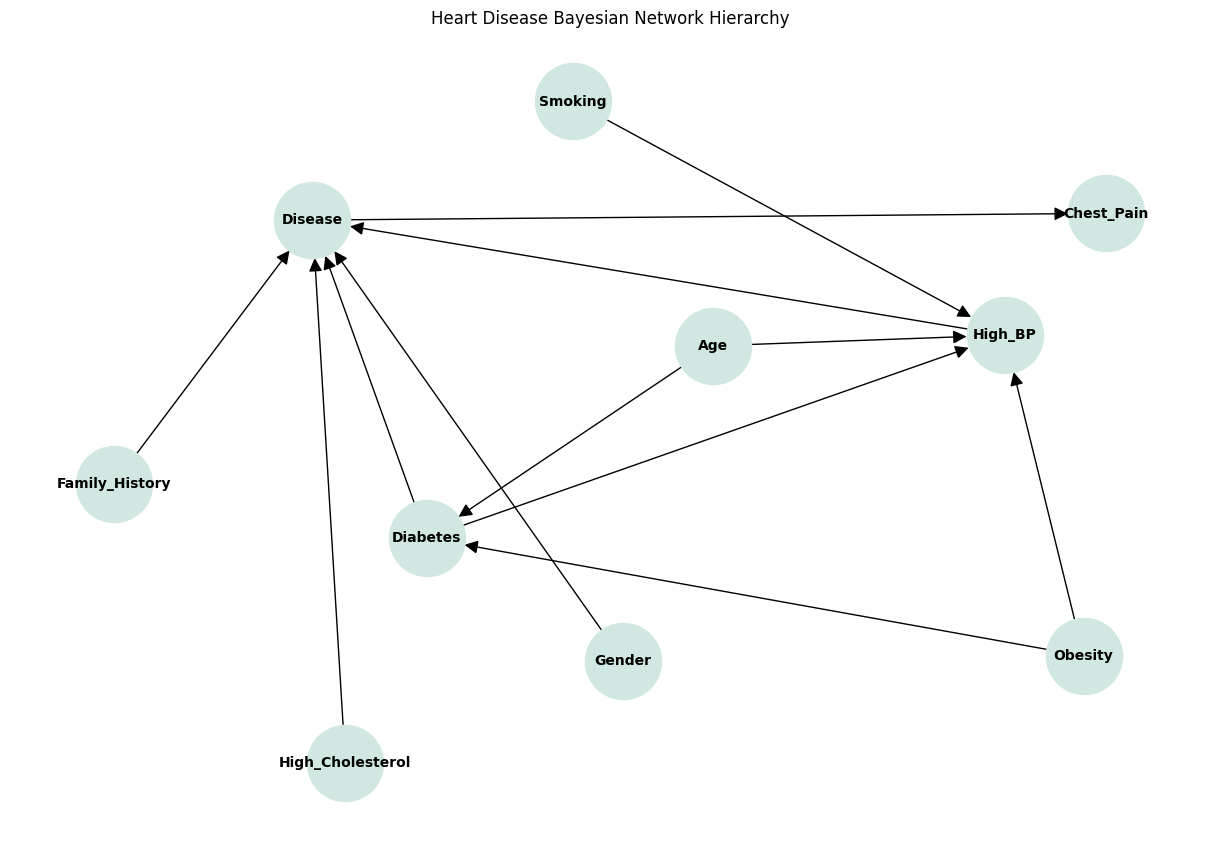

In [69]:
# 7. Visualize the Network DAG
# Converts the PGM structure to a NetworkX graph for a clear medical flow visualization.
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G, k=1.5, seed=42)

nx.draw(G, pos, with_labels=True, node_size=3000, node_color='#D1E8E2', font_size=10, font_weight='bold', arrowsize=20)
plt.title('Heart Disease Bayesian Network Hierarchy')
plt.show()

In [67]:
# 8. Advanced What-If Analysis Engine
# Quantifies how changing one risk factor (e.g., Blood Pressure) impacts the final probability.
def advanced_heart_risk_analysis(patient_data, toggle_factor=None):
    infer_eng = VariableElimination(model)
    evidence = {k: str(v) for k, v in patient_data.items() if k in model.nodes() and k != 'Disease'}

    res = infer_eng.query(variables=['Disease'], evidence=evidence, show_progress=False)
    base_risk = res.values[1]

    print(f"Base Risk: {base_risk:.4f}")

    if toggle_factor and toggle_factor in evidence:
        mod_evidence = evidence.copy()
        mod_evidence[toggle_factor] = '0.0' if evidence[toggle_factor] == '1.0' else '1.0'
        new_risk = infer_eng.query(variables=['Disease'], evidence=mod_evidence, show_progress=False).values[1]
        print(f"Risk after toggling {toggle_factor}: {new_risk:.4f} (Change: {new_risk - base_risk:.4f})")

In [ ]:
# 9. Export the trained model for Deployment
# Saves the model object using pickle and triggers a browser download for Streamlit use.
import pickle
from google.colab import files

model_filename = 'heart_disease_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

print(f"Model saved as {model_filename}")
files.download(model_filename)